# Irradiance Sample Bake Visualization

Load a Falcor `.irradiance-samples.bin` file and inspect sample placement, irradiance values, and backface-validation statistics.

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd()
if repo_root.name == "NeuralLightGridLearning":
    repo_root = repo_root.parent

learning_dir = repo_root / "NeuralLightGridLearning"
if str(learning_dir) not in sys.path:
    sys.path.insert(0, str(learning_dir))

from irradiance_samples import load_irradiance_samples, plot_sample_positions, plot_samples_overview

sample_path = repo_root / "build/windows-vs2022/bin/Debug/baked_samples/BistroExterior.irradiance-samples.bin"
sample_path

WindowsPath('c:/OpenGothicRepo/Falcor/build/windows-vs2022/bin/Debug/baked_samples/BistroExterior.irradiance-samples.bin')

In [2]:
samples = load_irradiance_samples(sample_path)
samples.summary()

{'path': 'c:\\OpenGothicRepo\\Falcor\\build\\windows-vs2022\\bin\\Debug\\baked_samples\\BistroExterior.irradiance-samples.bin',
 'version': 2,
 'sample_count': 1000000,
 'surface_count': 520000,
 'volume_count': 480000,
 'header_surface_count': 520000,
 'surface_sample_ratio': 0.5199999809265137,
 'backface_threshold': 0.5,
 'surface_offset': 0.0012924143811687827,
 'position_min': [-62.458194732666016, -7.563165664672852, -87.9367446899414],
 'position_max': [111.30174255371094, 43.531978607177734, 96.4804458618164],
 'irradiance_min': [0.0, 0.0, 0.0],
 'irradiance_max': [40.659584045410156, 31.43716049194336, 21.49805450439453],
 'irradiance_mean': [1.0566389560699463,
  0.7958793044090271,
  0.4830794334411621],
 'luminance_min': 0.0,
 'luminance_max': 32.37357711791992,
 'luminance_mean': 0.828887403011322}

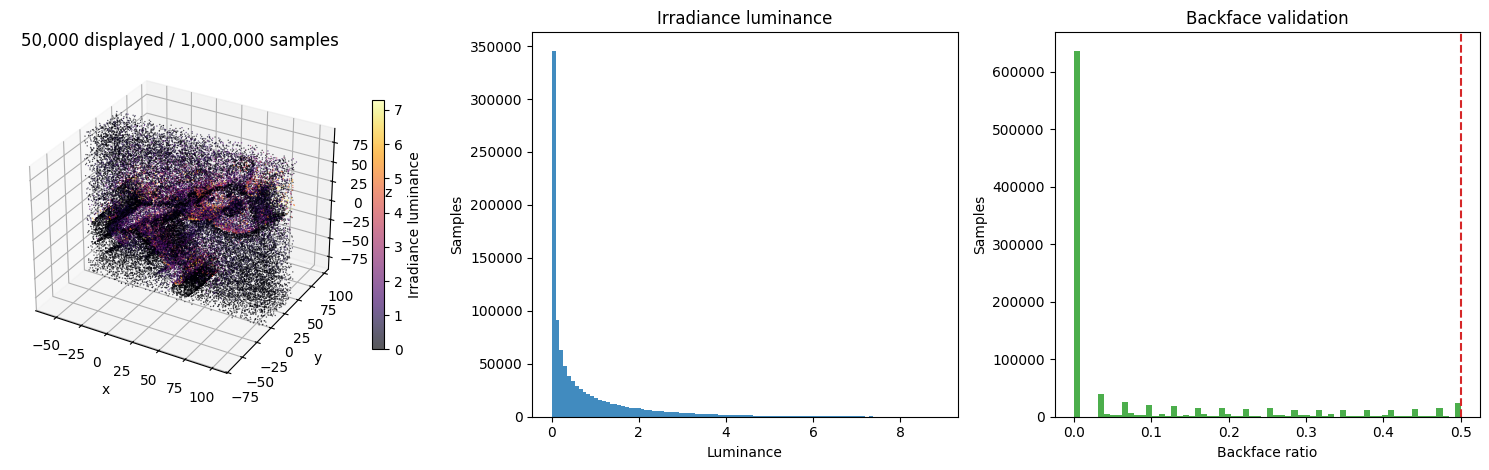

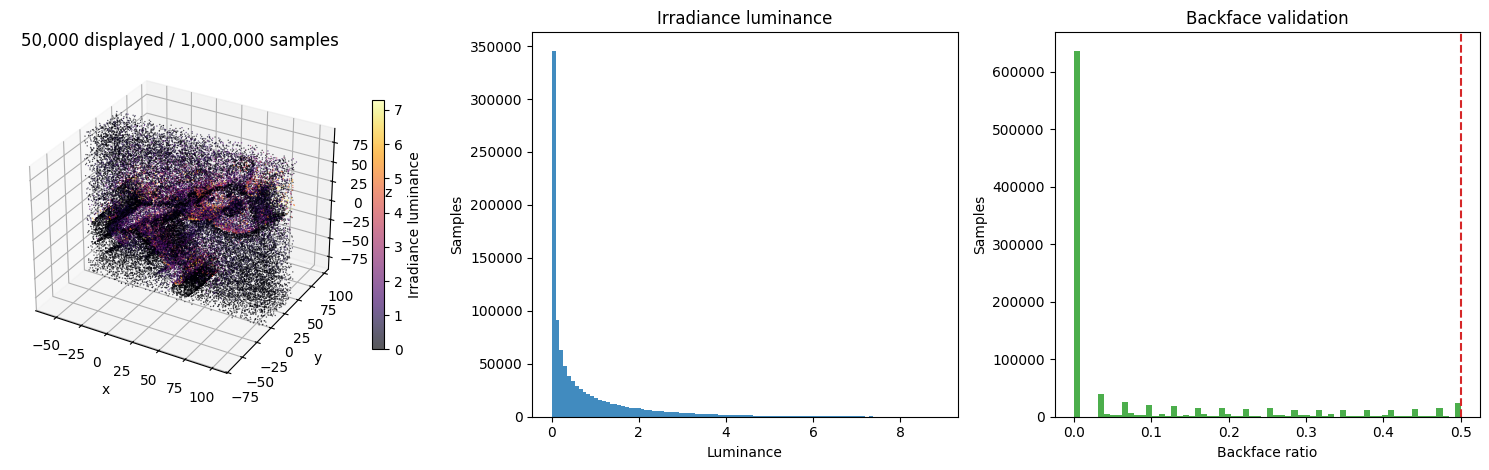

In [3]:
plot_samples_overview(samples, max_points=50_000, color_by="irradiance")

<Axes3D: title={'center': '1,000,000 displayed / 1,000,000 samples'}, xlabel='x', ylabel='y', zlabel='z'>

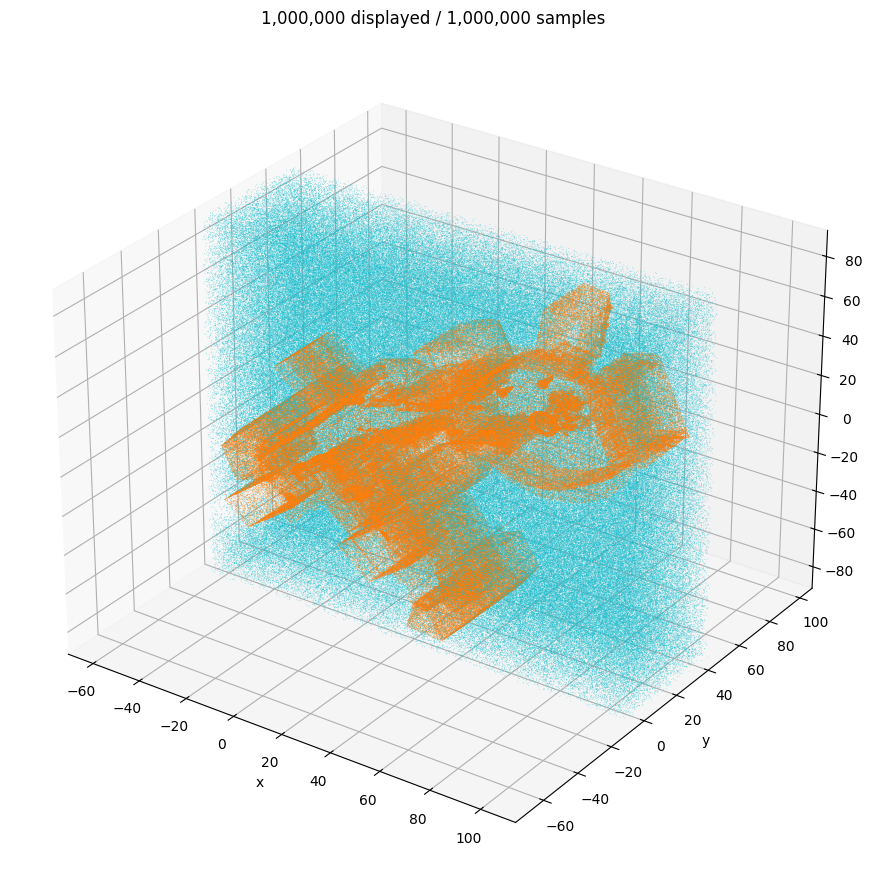

In [4]:
# Large scene-shaped view.
# This draws every sample. If VS Code becomes sluggish, set max_points back to 200_000 or 50_000.
ax = plot_sample_positions(
    samples,
    max_points=None,
    color_by="surface",
    figsize=(14, 11),
    point_size=0.35,
    alpha=0.55,
)
ax.view_init(elev=28, azim=-55)
ax